
Top 10 Features:

              Feature  Importance
2                 Age    0.251699
4             Balance    0.141130
8     EstimatedSalary    0.139183
1         CreditScore    0.133856
5       NumOfProducts    0.128791
3              Tenure    0.081981
7      IsActiveMember    0.036149
9   Geography_Germany    0.034229
11        Gender_Male    0.020620
6           HasCrCard    0.017437


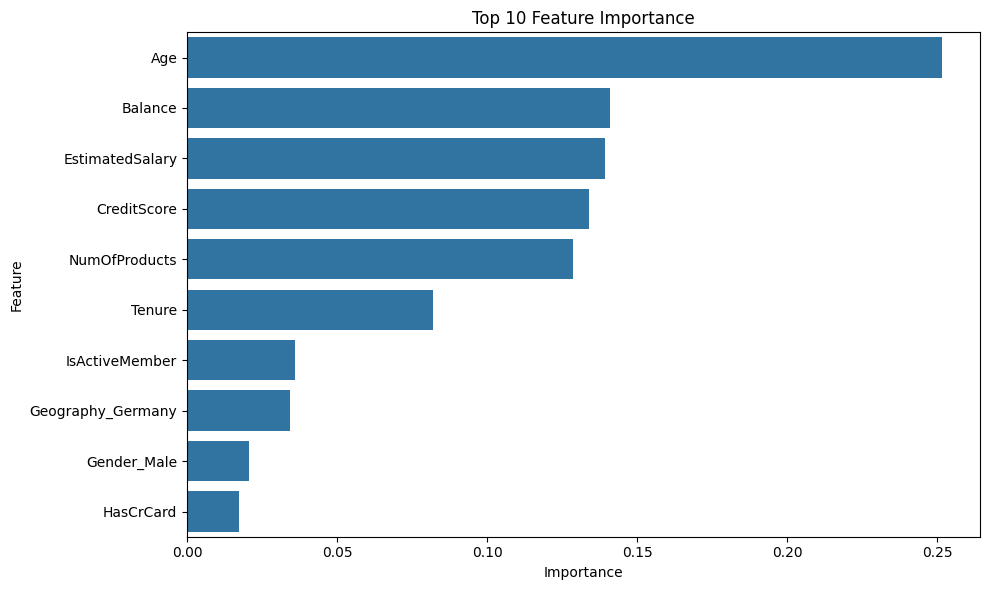

Dataset Shape: (10000, 12)

Shape Check:
y_test: (2000,)
y_pred: (2000,)
y_prob: (2000,)

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


================ ROC-AUC SCORE ================

ROC-AUC: 0.8525389796576238

================ CONFUSION MATRIX ================

[[1542   51]
 [ 229  178]]


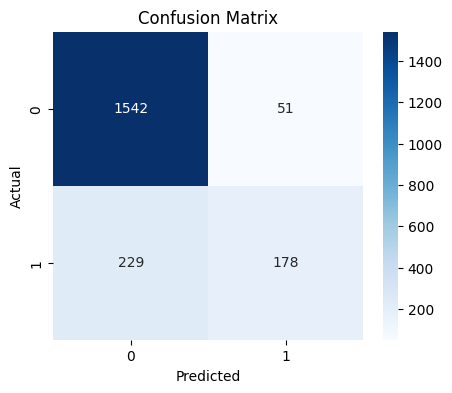

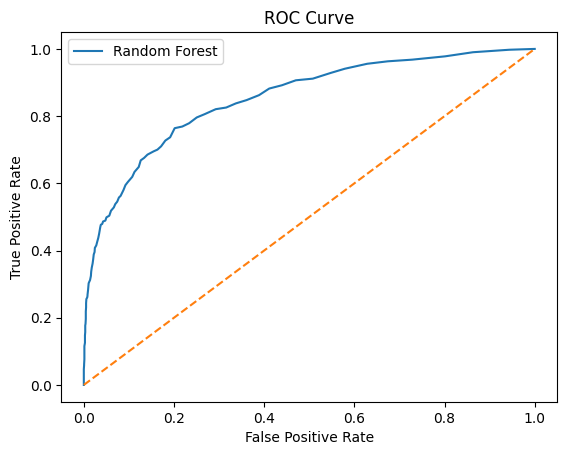

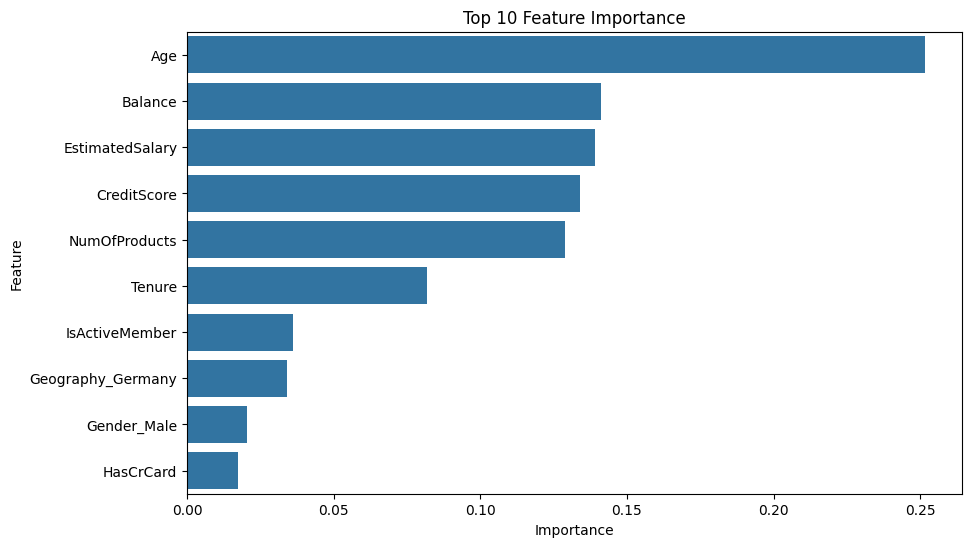

CHECK BEFORE EVALUATION
y_test unique: (array([0, 1]), array([1593,  407]))
y_pred unique: (array([0, 1]), array([1771,  229]))
y_prob range: 0.0 0.97

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


===== ROC-AUC =====

0.8525389796576238

===== CONFUSION MATRIX =====

[[1542   51]
 [ 229  178]]


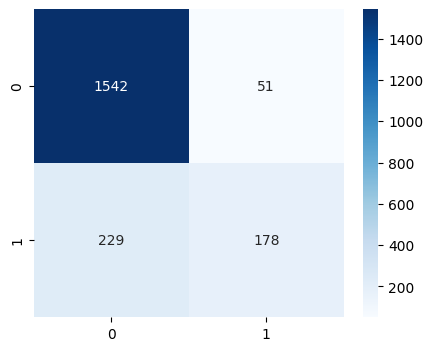

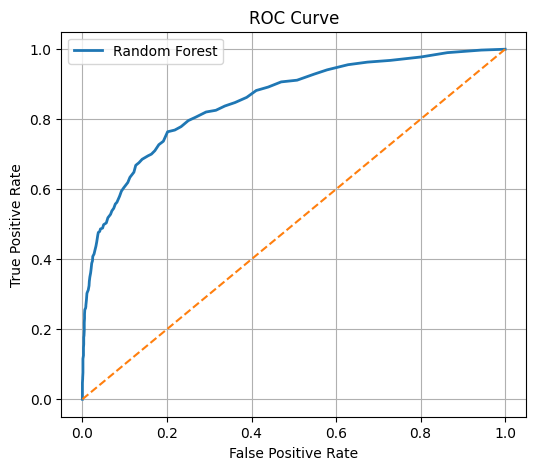

In [42]:

# -------------------------
# FEATURE IMPORTANCE (FINAL FIX)
# -------------------------

importances = model.feature_importances_

# FIX: use columns from TRAINED data (NOT original X)
feature_names = X_train.shape[1]

feature_names = X.columns.tolist()

# SAFETY CHECK (IMPORTANT)
if len(importances) != len(feature_names):
    print("Mismatch detected:", len(importances), len(feature_names))
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

print("\nTop 10 Features:\n")
print(feat_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()


# =========================
# BANK CHURN PREDICTION
# EUROPEAN BANK DATASET
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# -------------------------
# LOAD DATASET
# -------------------------
df = pd.read_csv("European_Bank.csv.csv")

# -------------------------
# CLEANING
# -------------------------
df = df.drop(columns=[col for col in ['CustomerId', 'Surname'] if col in df.columns])

print("Dataset Shape:", df.shape)

# -------------------------
# ENCODING
# -------------------------
df = pd.get_dummies(df, drop_first=True)

# -------------------------
# FEATURES / TARGET
# -------------------------
X = df.drop('Exited', axis=1)
y = df['Exited']
feature_names = X.columns
# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# SCALING
# -------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# MODEL
# -------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# PREDICTIONS
# -------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -------------------------
# SAFE CHECK (IMPORTANT)
# -------------------------
print("\nShape Check:")
print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

# -------------------------
# CLASSIFICATION REPORT
# -------------------------
print("\n================ CLASSIFICATION REPORT ================\n")
print(classification_report(y_test, y_pred, zero_division=0))

# -------------------------
# ROC-AUC
# -------------------------
roc_score = roc_auc_score(y_test, y_prob)
print("\n================ ROC-AUC SCORE ================\n")
print("ROC-AUC:", roc_score)

# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(y_test, y_pred)

print("\n================ CONFUSION MATRIX ================\n")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# ROC CURVE
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------
# FEATURE IMPORTANCE
# -------------------------
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Feature Importance")
plt.show()
print("CHECK BEFORE EVALUATION")
print("y_test unique:", np.unique(y_test, return_counts=True))
print("y_pred unique:", np.unique(y_pred, return_counts=True))
print("y_prob range:", y_prob.min(), y_prob.max())
# =========================
# SAFE EVALUATION BLOCK
# =========================

print("\n===== CLASSIFICATION REPORT =====\n")
try:
    print(classification_report(y_test, y_pred, zero_division=0))
except Exception as e:
    print("ERROR in classification report:", e)

print("\n===== ROC-AUC =====\n")
try:
    print(roc_auc_score(y_test, y_prob))
except Exception as e:
    print("ERROR in ROC-AUC:", e)

print("\n===== CONFUSION MATRIX =====\n")
try:
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()

except Exception as e:
    print("ERROR in confusion matrix:", e)
    # -------------------------

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()